## 📘 Детекція обʼєктів та розпізнання облич

---

## 🚀 Вступ  

У цій лекції продовжуємо тему комп’ютерного зору та розглядаємо інші важливі задачі, що виходять за межі класифікації та сегментації.

🔬 **Основні задачі комп’ютерного зору**:  
- 🔍 Класифікація зображень: визначення об’єктів (наприклад, кіт чи собака).  
- 🎯 Детекція об’єктів: знаходження та ідентифікація об’єктів.  
- 🖼 Сегментація: поділ зображення на значущі регіони.  
- 📷 Розпізнавання тексту та облич: OCR, біометрія.  
- 🩺 Медична діагностика: аналіз МРТ, рентгенів.  

Комп’ютерний зір використовується в автономних автомобілях, системах безпеки, AR/VR та соціальних мережах!  

---

## 🎯 Детекція об’єктів (Object Detection)

**Детекція об’єктів** — це задача комп’ютерного зору, де модель не лише визначає, *що* зображено, але й *де саме* це знаходиться на зображенні. Вихід моделі — це **обмежувальні прямокутники (bounding boxes)** з класами об’єктів.

![image](https://www.visionplatform.ai/wp-content/uploads/2024/01/object-detection.png)

### 📦 Як працює:
Модель приймає зображення на вхід і повертає:
- координати прямокутника навколо об’єкта (`x, y, width, height`)
- клас об’єкта (наприклад, *людина*, *авто*, *пес*)
- ймовірність передбачення (confidence score)

## 🧱 Архітектури

Архітектуру моделі детекціі обʼєктів так само можно умовно розділити на:
- **feature extraction (backbone)** - модуль для вилучення стійких ознак
- **detection head** - модуль для прогнозування детекцій.
- **neck (опціонально)** - іноді можна ще окремо виділиту так звану шию - компонент котрий що об’єднує ознаки з різних рівнів (наприклад, FPN, BiFPN). Він допомогає справлятися з обʼєктами різних розмерів
Коли ми говоримо про архітектуру моделей детекціі обʼєктів, зазвичай ми в першу чергу говоримо про голову.

Нижче приведені основні три типи архітектур детекціі обʼєктів, базуючись здебільшого саме на відмінностях голови.

### 🔁 Двокрокова детекція

Двокрокові (two-stage) моделі спочатку **генерують регіони-пропозиції** (Region Proposals), а потім **класифікують і уточнюють** їх. Такий підхід забезпечує **високу точність**, але працює повільніше.

- **Faster R-CNN** — класична двокрокова архітектура:
  - Перший етап: Region Proposal Network (RPN) пропонує області на зображенні, де можуть бути обʼєкти.
  - Другий етап: класифікація кожної області та регресія координат.
- Переваги: точність, хороша генералізація.
- Недоліки: більший час обробки, складніша архітектура.

### ⚡ Однокрокова детекція

Однокрокові (one-stage) моделі **прямо передбачають обмежувальні рамки та класи** з повного зображення без попереднього етапу.

- **YOLO (You Only Look Once)** — ділить зображення на сітку та для кожної комірки передбачає обʼєкти. Підходить для реального часу.
- **SSD (Single Shot MultiBox Detector)** — використовує кілька масштабів для детекції обʼєктів різного розміру.
- **RetinaNet** - однокрокова модель з фокусом на важкі приклади. Запропонувала focal loss, яка дозволяє боротися з дисбалансом між простими (фон) та складними прикладами (обʼєкти).
- **EfficientDet** - one-stage детектор на основі EfficientNet + BiFPN
- Переваги: швидкість, простота.
- Недоліки: дещо нижча точність, особливо для дрібних обʼєктів.

### 🧩 DETR (DEtection TRansformer)

**DETR** — новітній підхід до детекції, який використовує **трансформери** замість звичних CNN-регіональних підходів.

- В основі лежить **encoder–decoder трансформер**, що напряму передбачає фіксовану кількість обʼєктів у сцені.
- Позбавляється від anchor boxes, NMS (Non-Max Suppression) і спеціалізованих механізмів постобробки.
- Дає простішу архітектуру та кращу узагальненість, але **повільніший тренінг** і **більша потреба в даних**.
- Варіанти: **DETR**, **Deformable DETR**, **DINO**  **RT-DETR**(DETR with Improved Training)

---

## Популярні фреймворки

## 🧰 Популярні фреймворки

Для побудови та тренування моделей об'єктної детекції існує кілька потужних фреймворків, які значно спрощують роботу з сучасними архітектурами. Вони базуються на **pytorch**

### 🔷 Detectron2
- Розроблений Meta (Facebook AI Research).
- Підтримує **Faster R-CNN**, **RetinaNet**, **Mask R-CNN**, **DensePose** та інші.
- Написаний на PyTorch.
- Гнучкий, модульний, активно підтримується.
- Має готові конфіги, pre-trained моделі та API для інференсу й візуалізації.

🔗 https://github.com/facebookresearch/detectron2

---

### 🔷 MMDetection
- Частина OpenMMLab екосистеми (разом з MMEngine, MMCV тощо).
- Підтримує **понад 70+ архітектур**, включно з YOLO, Faster R-CNN, Cascade R-CNN, SSD, RetinaNet, ATSS, DINO та ін.
- Сильно конфігурований: модель описується YAML-конфігом без потреби писати код.
- Дуже популярний у наукових статтях.

🔗 https://github.com/open-mmlab/mmdetection

---

### 🔷 Ultralytics YOLO
- Підходить для навчання, інференсу, конверсії в ONNX/TFLite/CoreML.
- Має web-інтерфейс, CLI, Python API.
- Добре документований, активно розвивається.

🔗 https://github.com/ultralytics/ultralytics

---

### 🔷 Hugging Face Transformers + Vision
- Підтримка **DETR**, **DINO**, **OWL-ViT**, **ViTDet** та інших сучасних моделей на базі трансформерів.
- Працює через `transformers` + `datasets` + `accelerate`.
- Зручно для швидкого fine-tuning на своїх даних.
- Інтеграція з Hub для завантаження моделей.

🔗 https://huggingface.co/models?pipeline_tag=object-detection

---

### ⚙️ Ключові метрики:
- **IoU (Intersection over Union)** — міряє, наскільки добре передбачене вікно співпадає з правильним
- **mAP (mean Average Precision)** — середня точність для всіх класів і об’єктів

### 📈 Застосування:
- Відеоспостереження (виявлення людей, автомобілів)
- Автономні авто (розпізнавання дорожніх знаків, інших машин)
- Інвентаризація в магазинах (виявлення товарів на полицях)
- Медицина (виявлення пухлин або аномалій)

In [1]:
import tarfile  # Імпортуємо модуль для роботи з архівами TAR
import urllib.request  # Імпортуємо модуль для завантаження файлів з Інтернету

# URL файлів
images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"  # Вказуємо URL архіву із зображеннями
annotations_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"  # Вказуємо URL архіву з анотаціями

# Локальні файли
images_file = "images.tar.gz"  # Вказуємо ім'я файлу для збереження архіву із зображеннями
annotations_file = "annotations.tar.gz"  # Вказуємо ім'я файлу для збереження архіву з анотаціями

print("Завантаження зображень...")  # Виводимо повідомлення про початок завантаження зображень
urllib.request.urlretrieve(images_url, images_file)  # Завантажуємо архів із зображеннями та зберігаємо локально

print("Завантаження анотацій...")  # Виводимо повідомлення про початок завантаження анотацій
urllib.request.urlretrieve(annotations_url, annotations_file)  # Завантажуємо архів з анотаціями та зберігаємо локально

print("Розпакування images.tar.gz...")  # Виводимо повідомлення про початок розпакування зображень
with tarfile.open(images_file, "r:gz") as tar:  # Відкриваємо архів images.tar.gz для читання
    tar.extractall(".")  # Розпаковуємо всі файли архіву в поточну папку

print("Розпакування annotations.tar.gz...")  # Виводимо повідомлення про початок розпакування анотацій
with tarfile.open(annotations_file, "r:gz") as tar:  # Відкриваємо архів annotations.tar.gz для читання
    tar.extractall(".")  # Розпаковуємо всі файли архіву в поточну папку

print("Готово!")  # Виводимо повідомлення про завершення завантаження та розпакування

Завантаження зображень...
Завантаження анотацій...
Розпакування images.tar.gz...
Розпакування annotations.tar.gz...
Готово!


### Перетворення датасету в формат YOLO

In [2]:
import os
import shutil
import random

# Define paths
dataset_path = '' # assuming the images and annotations are in the current directory after extraction
images_dir = os.path.join(dataset_path, 'images')
annotations_dir = os.path.join(dataset_path, 'annotations/xmls')
output_dir = os.path.join(dataset_path, 'yolo_dataset')

# Create YOLO directory structure
os.makedirs(os.path.join(output_dir, 'images', 'train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'images', 'val'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'labels', 'train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'labels', 'val'), exist_ok=True)

# Get list of image files and their corresponding annotation files
image_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
annotation_files = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]

# Ensure images and annotations match
image_basenames = [os.path.splitext(f)[0] for f in image_files]
annotation_basenames = [os.path.splitext(f)[0] for f in annotation_files]

# Find common basenames (images that have corresponding annotations)
common_basenames = list(set(image_basenames) & set(annotation_basenames))

# Filter image and annotation files based on common basenames
filtered_image_files = [f + '.jpg' for f in common_basenames]
filtered_annotation_files = [f + '.xml' for f in common_basenames]

# Shuffle the data
combined = list(zip(filtered_image_files, filtered_annotation_files))
random.shuffle(combined)
filtered_image_files, filtered_annotation_files = zip(*combined)

# Define split ratios (e.g., 80% train, 20% validation)
train_split = int(len(filtered_image_files) * 0.8)

train_image_files = filtered_image_files[:train_split]
val_image_files = filtered_image_files[train_split:]

train_annotation_files = filtered_annotation_files[:train_split]
val_annotation_files = filtered_annotation_files[train_split:]

# Function to convert XML annotation to YOLO format
def convert_xml_to_yolo(xml_path, img_width, img_height, class_names):
    import xml.etree.ElementTree as ET

    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_annotations = []

    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name in class_names:
            class_id = class_names.index(class_name)

            bndbox = obj.find('bndbox')
            xmin = int(bndbox.find('xmin').text)
            ymin = int(bndbox.find('ymin').text)
            xmax = int(bndbox.find('xmax').text)
            ymax = int(bndbox.find('ymax').text)

            # Convert to YOLO format (center_x, center_y, width, height)
            center_x = (xmin + xmax) / 2.0 / img_width
            center_y = (ymin + ymax) / 2.0 / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            yolo_annotations.append(f"{class_id} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}")
        else:
            print(f"Warning: Class '{class_name}' not found in class_names. Skipping annotation in {xml_path}")


    return yolo_annotations

# Get unique class names from annotations (you might need to inspect your dataset for this)
# For the Oxford-IIIT Pet dataset, the class names are the breed names.
# We'll extract them from the filenames or the XMLs.
# Let's extract from XMLs for accuracy.
all_class_names = set()
for xml_file in filtered_annotation_files:
    import xml.etree.ElementTree as ET
    tree = ET.parse(os.path.join(annotations_dir, xml_file))
    root = tree.getroot()
    for obj in root.findall('object'):
        all_class_names.add(obj.find('name').text)

class_names = sorted(list(all_class_names))
print(f"Found {len(class_names)} classes: {class_names}")

# Process and copy files for training
print("Processing training data...")
for img_file, xml_file in zip(train_image_files, train_annotation_files):
    img_path = os.path.join(images_dir, img_file)
    xml_path = os.path.join(annotations_dir, xml_file)
    label_filename = os.path.splitext(img_file)[0] + '.txt'
    label_path = os.path.join(output_dir, 'labels', 'train', label_filename)

    # Need image dimensions to normalize bounding box coordinates
    from PIL import Image
    with Image.open(img_path) as img:
        img_width, img_height = img.size

    yolo_annotations = convert_xml_to_yolo(xml_path, img_width, img_height, class_names)

    if yolo_annotations: # Only create label file if there are annotations
        with open(label_path, 'w') as f:
            for line in yolo_annotations:
                f.write(line + '\n')

        # Copy image file
        shutil.copy(img_path, os.path.join(output_dir, 'images', 'train', img_file))
    else:
        print(f"No valid annotations found for {img_file}. Skipping.")


# Process and copy files for validation
print("Processing validation data...")
for img_file, xml_file in zip(val_image_files, val_annotation_files):
    img_path = os.path.join(images_dir, img_file)
    xml_path = os.path.join(annotations_dir, xml_file)
    label_filename = os.path.splitext(img_file)[0] + '.txt'
    label_path = os.path.join(output_dir, 'labels', 'val', label_filename)

    from PIL import Image
    with Image.open(img_path) as img:
        img_width, img_height = img.size

    yolo_annotations = convert_xml_to_yolo(xml_path, img_width, img_height, class_names)

    if yolo_annotations: # Only create label file if there are annotations
        with open(label_path, 'w') as f:
            for line in yolo_annotations:
                f.write(line + '\n')

        # Copy image file
        shutil.copy(img_path, os.path.join(output_dir, 'images', 'val', img_file))
    else:
        print(f"No valid annotations found for {img_file}. Skipping.")

print("Dataset preparation complete.")
print(f"YOLO dataset structure created in: {output_dir}")

# Create a data.yaml file for YOLO
data_yaml_content = f"""
path: ../yolo_dataset  # dataset root dir
train: images/train  # train images (relative to 'path') 128 images
val: images/val  # val images (relative to 'path') 128 images

nc: {len(class_names)}  # number of classes
names: {class_names}  # class names
"""

with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
    f.write(data_yaml_content)

print(f"data.yaml created in {output_dir}")

# Example of how you might start training with Ultralytics YOLOv8
# This is commented out, you wofould typically run this in a new cell
# from ultralytics import YOLO
#
# # Load a model
# model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for transfer learning)
# # model = YOLO('yolov8n.yaml') # create a new model from scratch
#
# # Train the model
# results = model.train(data=os.path.join(output_dir, 'data.yaml'), epochs=100, imgsz=640)
 

Found 2 classes: ['cat', 'dog']
Processing training data...
Processing validation data...
Dataset preparation complete.
YOLO dataset structure created in: yolo_dataset
data.yaml created in yolo_dataset


In [3]:
yaml_content = """path: ./yolo_dataset
train: images
val: images

nc: 2
names: ['cat', 'dog']
"""

with open("dataset.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_content)

print("Файл dataset.yaml успішно створено!")

Файл dataset.yaml успішно створено!


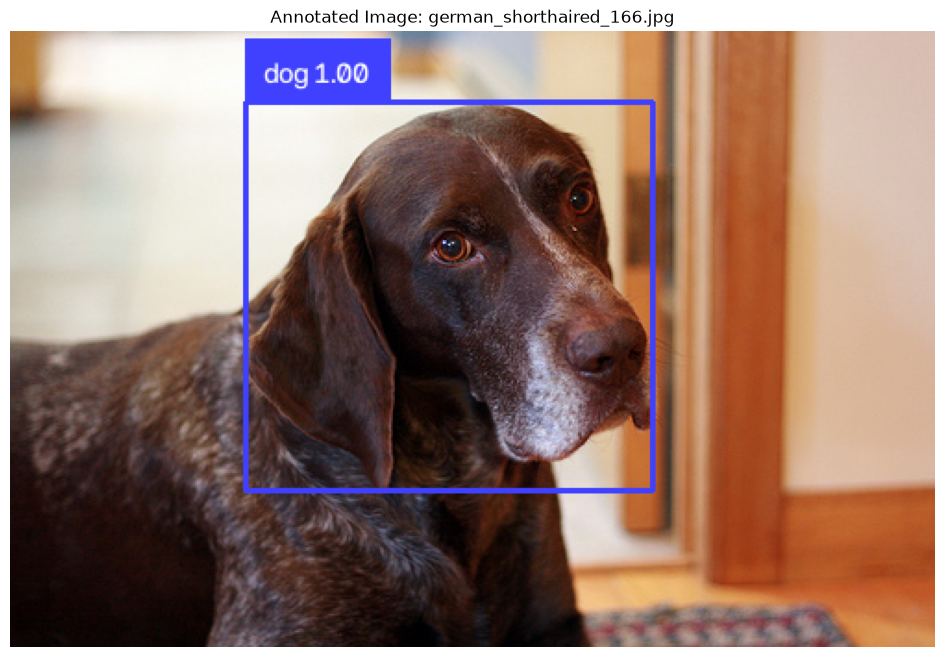

In [7]:

import numpy as np
import supervision as sv
import cv2
import matplotlib.pyplot as plt

# Choose a random image from the validation set
if val_image_files:
    random_image_name = random.choice(val_image_files)
    random_image_path = os.path.join(output_dir, 'images', 'val', random_image_name)
    random_label_path = os.path.join(output_dir, 'labels', 'val', os.path.splitext(random_image_name)[0] + '.txt')

    # Read the image
    image = cv2.imread(random_image_path)
    # Convert from BGR to RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read the YOLO format annotations
    detections = []
    if os.path.exists(random_label_path):
        with open(random_label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    center_x, center_y, width, height = map(float, parts[1:])
                    detections.append([class_id, center_x, center_y, width, height])

    # Convert YOLO format to Supervision Detections format (xyxy)
    # Supervision expects xyxy format where coordinates are absolute pixel values
    image_height, image_width, _ = image.shape
    xyxy = []
    confidence = [] # YOLO labels don't have confidence, use a placeholder
    class_id_list = []

    for det in detections:
        class_id, center_x_norm, center_y_norm, width_norm, height_norm = det

        center_x = center_x_norm * image_width
        center_y = center_y_norm * image_height
        width = width_norm * image_width
        height = height_norm * image_height

        x_min = center_x - width / 2
        y_min = center_y - height / 2
        x_max = center_x + width / 2
        y_max = center_y + height / 2

        xyxy.append([x_min, y_min, x_max, y_max])
        confidence.append(1.0) # Placeholder confidence
        class_id_list.append(class_id)

    # Create Supervision Detections object
    detections_sv = sv.Detections(
        xyxy=np.array(xyxy),
        confidence=np.array(confidence),
        class_id=np.array(class_id_list)
    )

    # Initialize Supervision annotators
    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=0.5)

    # Create labels for annotator
    # Need to handle cases where class_id might be out of bounds for class_names
    labels = [
        f"{class_names[class_id]} {confidence:.2f}" if class_id < len(class_names) else f"Unknown {confidence:.2f}"
        for class_id, confidence
        in zip(detections_sv.class_id, detections_sv.confidence)
    ]

    # Annotate the image
    annotated_image = bounding_box_annotator.annotate(scene=image.copy(), detections=detections_sv)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections_sv, labels=labels)

    # Display the annotated image
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image)
    plt.title(f"Annotated Image: {random_image_name}")
    plt.axis('off')
    plt.show()

else:
    print("Validation set is empty, cannot visualize.")
 

In [8]:
dataset_config_path = 'dataset.yaml' # Replace with the actual path to your dataset config

# Define the model to use (e.g., yolov8n.pt for nano version, yolov8m.pt for medium)
# You can download pre-trained weights or train from scratch.
model_name = 'yolov8n.pt'

# Define training parameters
epochs = 2 # Number of training epochs
imgsz = 640 # Image size
batch_size = 64 # Batch size

# Import the YOLO model
from ultralytics import YOLO

# Load a model
model = YOLO(model_name)  # load a pretrained model (recommended for transfer learning)

# Train the model
results = model.train(
    data=dataset_config_path,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    device="cpu"  # 0 = перша GPU. Для кількох GPU: device=[0,1]
)

metrics = model.val(device="cpu")

# Print metrics (example: mAP50)
print("mAP50:", metrics.box.map50)

# You can also save the trained model
# model.save('trained_pet_detector.pt')

# To use the trained model for inference:
# from ultralytics import YOLO
# model = YOLO('runs/detect/train/weights/best.pt') # Load your best trained model
# results = model('path/to/your/image.jpg') # Run inference on an image

# This is a basic example. You might need to adjust parameters,
# handle data preprocessing (converting annotations to YOLO format),
# and explore more advanced configurations based on your dataset and goals.

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\user\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.132  Python-3.14.3 torch-2.13.0+cpu CPU (AMD Ryzen 5 8400F 6-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipu

### Візуалізація прогнозів


image 1/1 C:\Users\My data\data\Python-AI\Projects\lesson-16-NoTeacher2\yolo_dataset\images\val\scottish_terrier_153.jpg: 640x448 (no detections), 28.0ms
Speed: 1.4ms preprocess, 28.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 C:\Users\My data\data\Python-AI\Projects\lesson-16-NoTeacher2\yolo_dataset\images\val\Ragdoll_156.jpg: 640x544 1 cat, 45.0ms
Speed: 1.4ms preprocess, 45.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 C:\Users\My data\data\Python-AI\Projects\lesson-16-NoTeacher2\yolo_dataset\images\val\japanese_chin_163.jpg: 640x480 1 dog, 26.5ms
Speed: 1.2ms preprocess, 26.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\My data\data\Python-AI\Projects\lesson-16-NoTeacher2\yolo_dataset\images\val\american_bulldog_186.jpg: 640x480 1 dog, 27.0ms
Speed: 1.2ms preprocess, 27.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\My data\data\P

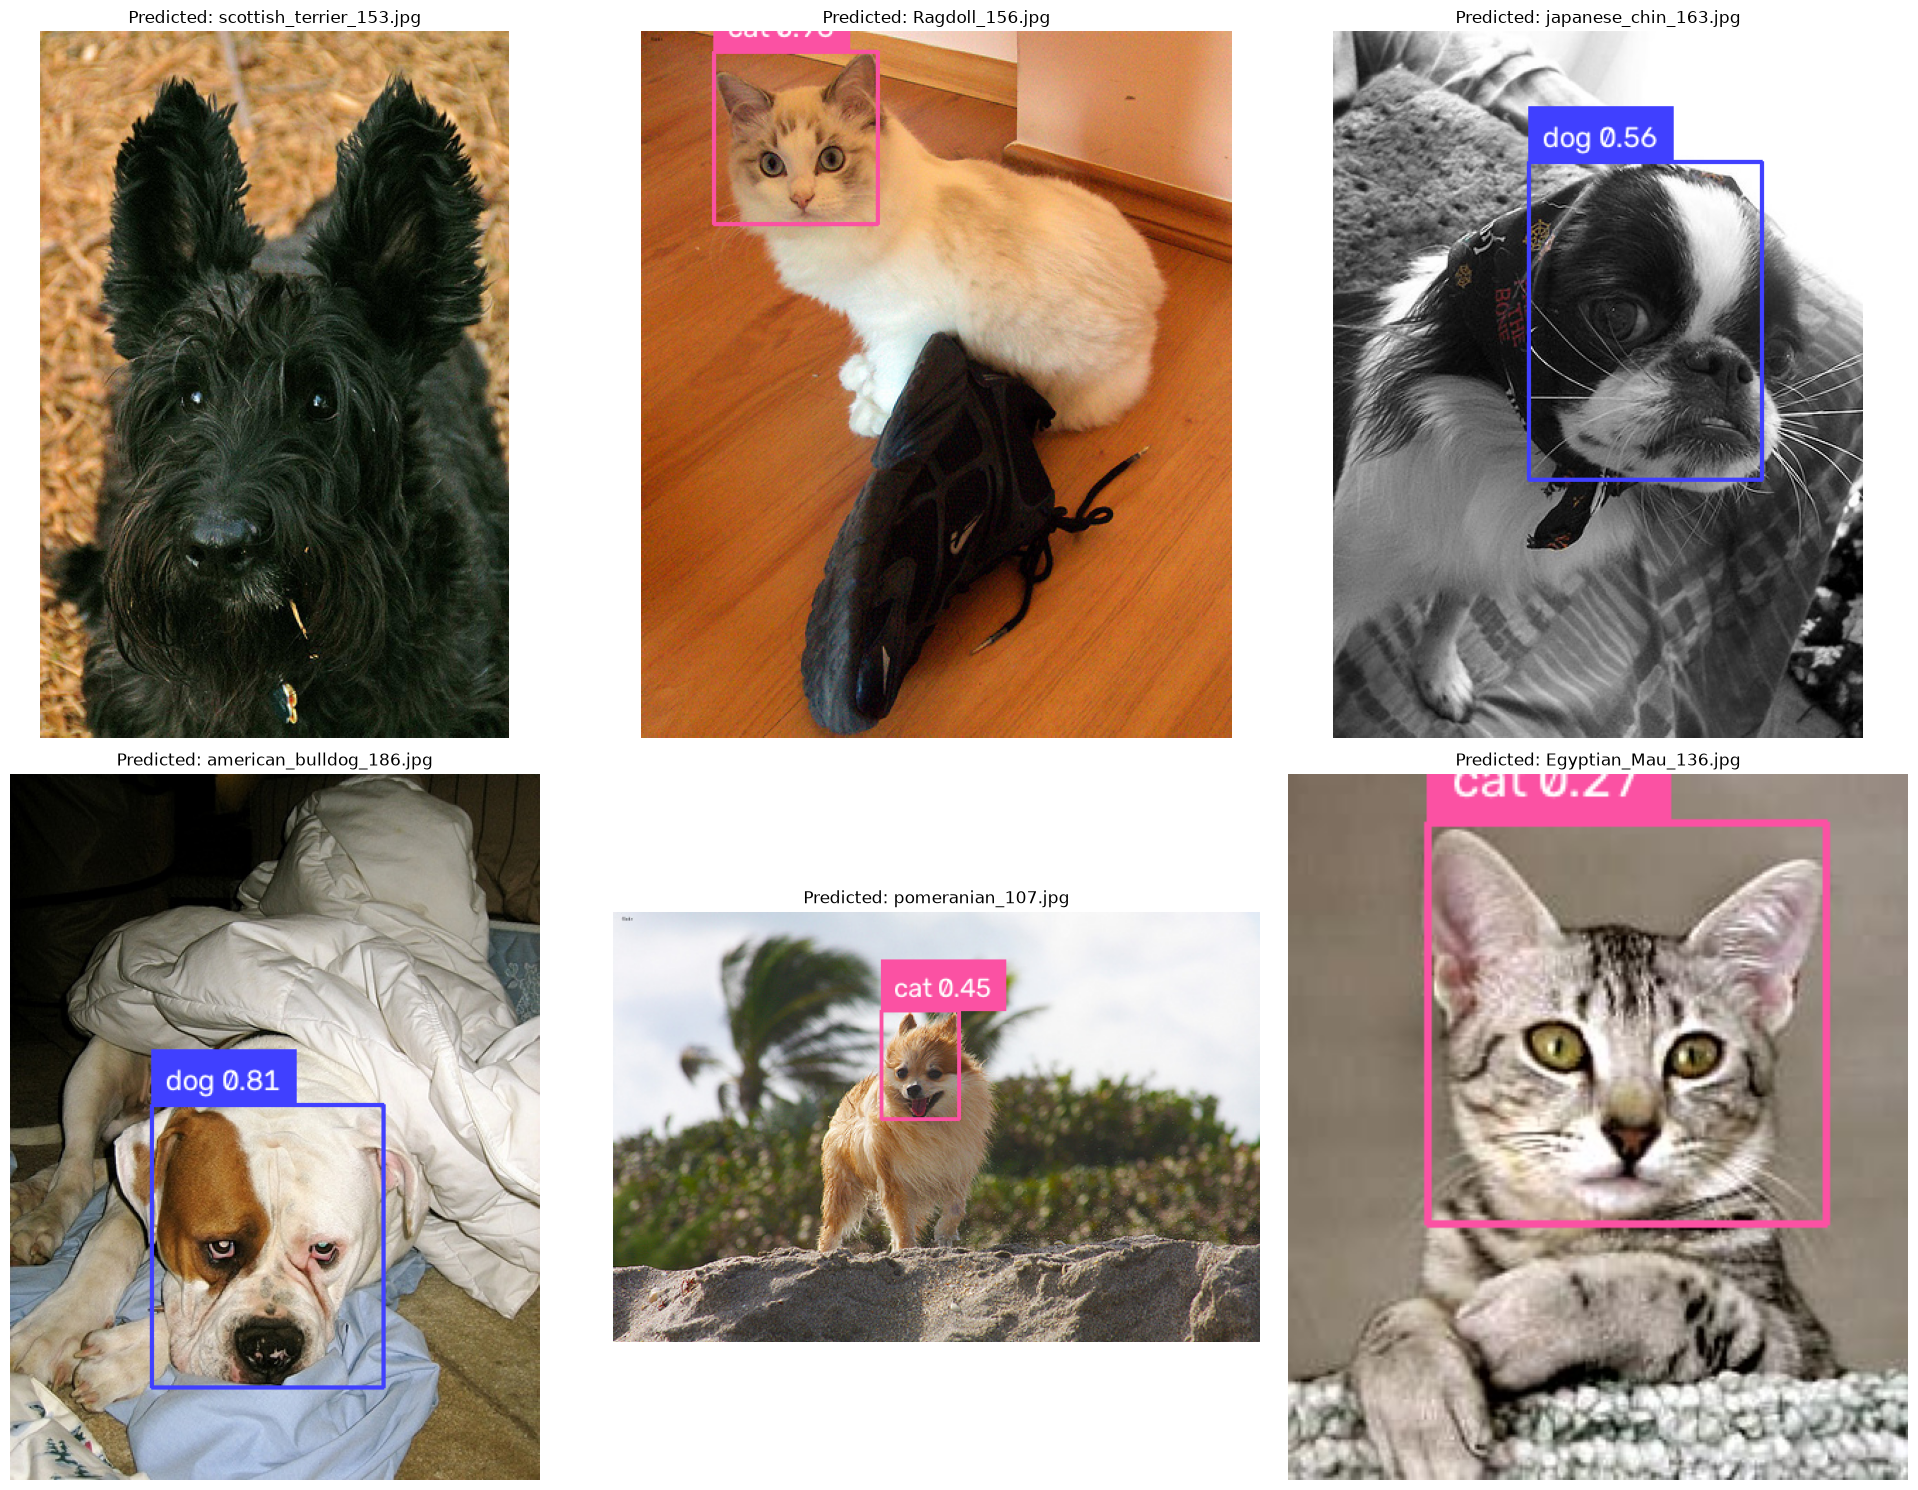

In [14]:
import matplotlib.pyplot as plt
# Get a list of random image paths from the validation set
random_image_files = random.sample(val_image_files, min(6, len(val_image_files)))

plt.figure(figsize=(20, 15))

for i, img_file in enumerate(random_image_files):
    img_path = os.path.join(output_dir, 'images', 'val', img_file)
    label_path = os.path.join(output_dir, 'labels', 'val', os.path.splitext(img_file)[0] + '.txt')

    # Read the image
    image = cv2.imread(img_path)
    # Convert from BGR to RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Run inference with the trained model
    # Assuming 'model' from the previous training step is available
    inference_results = model(img_path, stream=False) # Run inference on a single image

    # Extract detections from the results
    # The results object structure can vary slightly based on the YOLO version
    # For Ultralytics YOLOv8, results are typically in result.boxes
    detections_list = []
    if inference_results and hasattr(inference_results[0], 'boxes'):
        boxes = inference_results[0].boxes
        # boxes.xyxy: [N, 4] tensor of bounding box coordinates (x1, y1, x2, y2)
        # boxes.conf: [N] tensor of confidence scores
        # boxes.cls: [N] tensor of class IDs
        xyxy = boxes.xyxy.cpu().numpy()
        confidence = boxes.conf.cpu().numpy()
        class_id_list = boxes.cls.cpu().numpy().astype(int)

        detections_sv = sv.Detections(
            xyxy=xyxy,
            confidence=confidence,
            class_id=class_id_list
        )
    else:
        # Handle cases where no detections are found or result structure is different
        detections_sv = sv.Detections.empty()
        print(f"No detections found for {img_file} or unexpected results format.")

    # Initialize Supervision annotators
    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=0.7, text_thickness=1)

    # Create labels for annotator using predicted class IDs and confidence
    # Need to handle cases where class_id might be out of bounds for class_names (unlikely with trained model)
    labels = [
        f"{class_names[class_id]} {confidence:.2f}" if class_id < len(class_names) else f"Unknown {confidence:.2f}"
        for class_id, confidence
        in zip(detections_sv.class_id, detections_sv.confidence)
    ]

    # Annotate the image
    annotated_image = bounding_box_annotator.annotate(scene=image.copy(), detections=detections_sv)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections_sv, labels=labels)

    # Display the annotated image
    plt.subplot(2, 3, i + 1) # Create a 2x5 grid of subplots
    plt.imshow(annotated_image)
    plt.title(f"Predicted: {img_file}")
    plt.axis('off')

plt.tight_layout()
plt.show()